# **Capstone 2: Sales Territory Analysis**

Prepared by: Marenza Santarin

### **Project Overview**

This project analyzes sales performance across EmporiUm bookstore territories by using Python, Pandas, NumPy, and Matplotlib.

The sales territories analyzed in this project are:

**Colorado Territory (West Region)** | **Territory Manager:** Jim Heck

**New Jersey Territory (Northeast Region)** | **Territory Manager:** Miami Vue

The purpose of this analysis is to evaluate:

- Sales performance
- Monthly revenue trends
- Store performance
- Customer purchasing behavior
- Product category trends

Based on the findings, recommendations will be provided on where marketing efforts should focus next quarter.

In [32]:
# Importing libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Data Import and Inspection

In this section, each dataset will be loaded and inspected to understand its structure, column names, data types, and available information before beginning the analysis.

In [33]:
# Loading StoreSales.csv
df_sales = pd.read_csv("StoreSales.csv")

# Inspecting the dataset
df_sales.info()

# Previewing first 5 rows
df_sales.head()

# Checking dimensions
df_sales.shape

<class 'pandas.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  str    
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  str    
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 12.8 MB


(335129, 5)

In [34]:
# Loading StoreDetail.csv
df_stores = pd.read_csv("StoreDetail.csv")

# Inspecting the dataset
df_stores.info()

# Previewing first 5 rows
df_stores.head()

# Checking dimensions
df_stores.shape

<class 'pandas.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Store Location     111 non-null    str  
 1   State              111 non-null    str  
 2   Store ID           111 non-null    int64
 3   Territory Manager  111 non-null    str  
 4   Region             111 non-null    str  
 5   Region Director    111 non-null    str  
dtypes: int64(1), str(5)
memory usage: 5.3 KB


(111, 6)

In [35]:
# Loading Products.csv
df_products = pd.read_csv("Products.csv")

# Inspecting the dataset
df_products.info()

# Previewing first 5 rows
df_products.head()

# Checking dimensions
df_products.shape

<class 'pandas.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Prod Num       669 non-null    str  
 1   Product        669 non-null    str  
 2   CategoryID     669 non-null    int64
 3   SubcategoryID  669 non-null    str  
dtypes: int64(1), str(3)
memory usage: 21.0 KB


(669, 4)

In [36]:
# Loading ProductCategories.csv
df_categories = pd.read_csv("ProductCategories.csv")

# Inspecting the dataset
df_categories.info()

# Previewing first 5 rows
df_categories.head()

# Checking dimensions
df_categories.shape

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CategoryID     52 non-null     int64
 1   Category       52 non-null     str  
 2   SubcategoryID  52 non-null     str  
 3   Subcategory    52 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.8 KB


(52, 4)

In [37]:
# Loading customer_list.csv
df_customers = pd.read_csv(
    "customer_list.csv",
    sep="|"
)
# Using sep="|"" because this file is pipe-separated instead of comma-separated

# Inspecting the dataset
df_customers.info()

# Previewing first 5 rows
df_customers.head()

# Checking dimensions
df_customers.shape

<class 'pandas.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   cust_id       521 non-null    int64
 1   date          521 non-null    str  
 2   time          521 non-null    str  
 3   name          521 non-null    str  
 4   email         521 non-null    str  
 5   phone         520 non-null    str  
 6   sms-opt-out   520 non-null    str  
dtypes: int64(1), str(6)
memory usage: 28.6 KB


(521, 7)

## Core Marketing Analysis

The following sections analyze sales performance in assigned sales territories, focusing on revenue trends, store performance, customer behavior, product category performance, and opportunities for future marketing efforts.

### Q1: Territory Managers, Store IDs, and Cities

This section identifies the territory managers and the stores in the Colorado and New Jersey sales areas.

In [38]:
# Filtering store information for assigned territories
df_territories = df_stores[
    df_stores['State'].isin([
        'Colorado',
        'New Jersey'
    ])
]

# Sorting for cleaner output
df_territories = df_territories.sort_values(
    by=['State', 'Store ID']
)

# Displaying results
df_territories

,Store Location,State,Store ID,Territory Manager,Region,Region Director
0,Aurora,Colorado,701,Jim Heck,West,Cassie Chambers
1,Berthoud,Colorado,702,Jim Heck,West,Cassie Chambers
2,Boulder,Colorado,703,Jim Heck,West,Cassie Chambers
3,Castle Rock,Colorado,704,Jim Heck,West,Cassie Chambers
4,Denver,Colorado,705,Jim Heck,West,Cassie Chambers
5,Englewood,Colorado,706,Jim Heck,West,Cassie Chambers
6,Fort Collins,Colorado,707,Jim Heck,West,Cassie Chambers
7,Grand Junction,Colorado,708,Jim Heck,West,Cassie Chambers
8,Greeley,Colorado,709,Jim Heck,West,Cassie Chambers
9,Lafayette,Colorado,710,Jim Heck,West,Cassie Chambers


Jim Heck manages the Colorado stores in the West Region, and Miami Vue oversees the New Jersey stores in the Northeast Region. Colorado has several store locations across the state, while New Jersey's stores are part of the Northeast territory. These stores will be the focus of my analysis as I compare sales performance, customer behavior, and product trends.

### Q2: Monthly Total Revenue by Territory

This section analyzes monthly total sales revenue for the Colorado and New Jersey sales territories throughout the dataset period.

In [39]:
# Merging sales and store data using Store ID
df_sales_stores = pd.merge(
    df_sales,
    df_territories,
    on='Store ID',
    how='inner'
)

# Preview merged data
df_sales_stores.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Store Location,State,Territory Manager,Region,Region Director
0,1/1/2022,702,NaN,105349-M,8.00,Berthoud,Colorado,Jim Heck,West,Cassie Chambers
1,1/1/2022,704,NaN,105350-T,144.00,Castle Rock,Colorado,Jim Heck,West,Cassie Chambers
2,1/1/2022,705,NaN,105351-M,44.00,Denver,Colorado,Jim Heck,West,Cassie Chambers
3,1/1/2022,705,NaN,105352-M,47.61,Denver,Colorado,Jim Heck,West,Cassie Chambers
4,1/1/2022,705,NaN,105353-A,20.36,Denver,Colorado,Jim Heck,West,Cassie Chambers


In [40]:
# Converting transaction date to datetime
# Because dates load as text first, it needs to be converted before working with months
df_sales_stores['Transaction Date'] = pd.to_datetime(
    df_sales_stores['Transaction Date']
)

# Confirm datatype changed
df_sales_stores.info()

<class 'pandas.DataFrame'>
RangeIndex: 84693 entries, 0 to 84692
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Transaction Date   84693 non-null  datetime64[us]
 1   Store ID           84693 non-null  int64         
 2   RewardsID          8874 non-null   float64       
 3   Prod Num           84693 non-null  str           
 4   Sale Amount        84693 non-null  float64       
 5   Store Location     84693 non-null  str           
 6   State              84693 non-null  str           
 7   Territory Manager  84693 non-null  str           
 8   Region             84693 non-null  str           
 9   Region Director    84693 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(6)
memory usage: 6.5 MB


In [41]:
# Creating YearMonth column
df_sales_stores['YearMonth'] = (
    df_sales_stores['Transaction Date']
    .dt.to_period('M')
)

# Preview result
df_sales_stores.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Store Location,State,Territory Manager,Region,Region Director,YearMonth
0,2022-01-01,702,NaN,105349-M,8.00,Berthoud,Colorado,Jim Heck,West,Cassie Chambers,2022-01
1,2022-01-01,704,NaN,105350-T,144.00,Castle Rock,Colorado,Jim Heck,West,Cassie Chambers,2022-01
2,2022-01-01,705,NaN,105351-M,44.00,Denver,Colorado,Jim Heck,West,Cassie Chambers,2022-01
3,2022-01-01,705,NaN,105352-M,47.61,Denver,Colorado,Jim Heck,West,Cassie Chambers,2022-01
4,2022-01-01,705,NaN,105353-A,20.36,Denver,Colorado,Jim Heck,West,Cassie Chambers,2022-01


In [42]:
# Monthly revenue by territory
monthly_revenue = (
    df_sales_stores
    .groupby(['YearMonth', 'State'])[
        'Sale Amount'
    ]
    .sum()
    .reset_index()
)

# Preview results
monthly_revenue.head()

,YearMonth,State,Sale Amount
0,2022-01,Colorado,77950.98
1,2022-01,New Jersey,70597.51
2,2022-02,Colorado,80315.69
3,2022-02,New Jersey,63225.69
4,2022-03,Colorado,82516.36


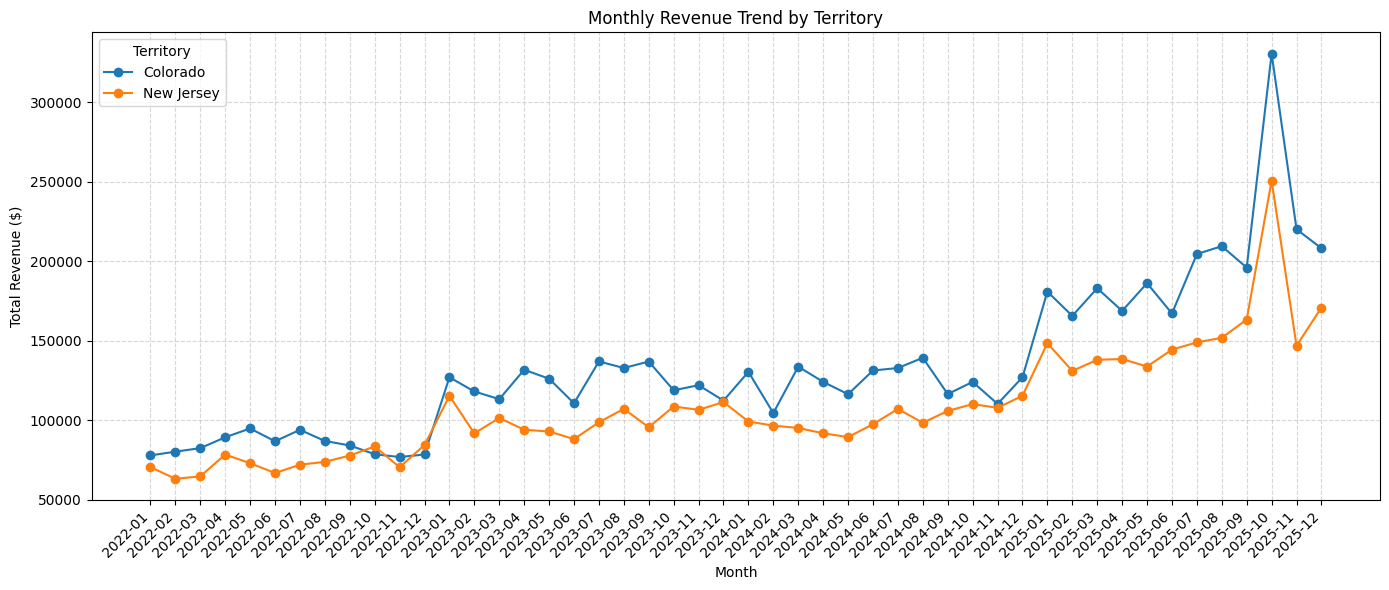

In [43]:
# Monthly revenue trend chart
plt.figure(figsize=(14, 6))

# Colorado line
co_data = monthly_revenue[
    monthly_revenue['State'] == 'Colorado'
]

plt.plot(
    co_data['YearMonth'].astype(str),
    co_data['Sale Amount'],
    marker='o',
    label='Colorado'
)

# New Jersey line
nj_data = monthly_revenue[
    monthly_revenue['State'] == 'New Jersey'
]

plt.plot(
    nj_data['YearMonth'].astype(str),
    nj_data['Sale Amount'],
    marker='o',
    label='New Jersey'
)

# Chart formatting
plt.title('Monthly Revenue Trend by Territory')
plt.xlabel('Month')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Territory')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Colorado brought in higher monthly revenue than New Jersey for most of the reporting period, with bigger revenue spikes and clear growth in 2025. New Jersey’s sales were steadier but stayed lower overall. Both states saw growth over time, which points to good opportunities for more marketing, especially during strong sales months.

### Q3: Store Performance Ranking

This section ranks store performance by total sales revenue within each assigned territory to highlight the top-performing locations.

In [44]:
# Ranking stores by total sales revenue within each territory
store_ranking = (
    df_sales_stores
    .groupby([
        'State',
        'Store ID',
        'Store Location'
    ])['Sale Amount']
    .sum()
    .reset_index()
)

# Sorting by territory first, then revenue highest to lowest
store_ranking = store_ranking.sort_values(
    by=['State', 'Sale Amount'],
    ascending=[True, False]
)

store_ranking

,State,Store ID,Store Location,Sale Amount
4,Colorado,705,Denver,917471.53
8,Colorado,709,Greeley,640368.11
5,Colorado,706,Englewood,344647.48
9,Colorado,710,Lafayette,337169.61
2,Colorado,703,Boulder,321197.88
15,Colorado,716,Sedalia,319776.13
0,Colorado,701,Aurora,317198.67
7,Colorado,708,Grand Junction,306834.49
6,Colorado,707,Fort Collins,302660.34
3,Colorado,704,Castle Rock,299122.02


In [45]:
# Adding rank within each territory
store_ranking['Rank'] = (
    store_ranking
    .groupby('State')['Sale Amount']
    .rank(
        method='dense',
        ascending=False
    )
    .astype(int)
)

store_ranking = store_ranking.sort_values(
    by=['State', 'Rank']
)

store_ranking

,State,Store ID,Store Location,Sale Amount,Rank
4,Colorado,705,Denver,917471.53,1
8,Colorado,709,Greeley,640368.11,2
5,Colorado,706,Englewood,344647.48,3
9,Colorado,710,Lafayette,337169.61,4
2,Colorado,703,Boulder,321197.88,5
15,Colorado,716,Sedalia,319776.13,6
0,Colorado,701,Aurora,317198.67,7
7,Colorado,708,Grand Junction,306834.49,8
6,Colorado,707,Fort Collins,302660.34,9
3,Colorado,704,Castle Rock,299122.02,10


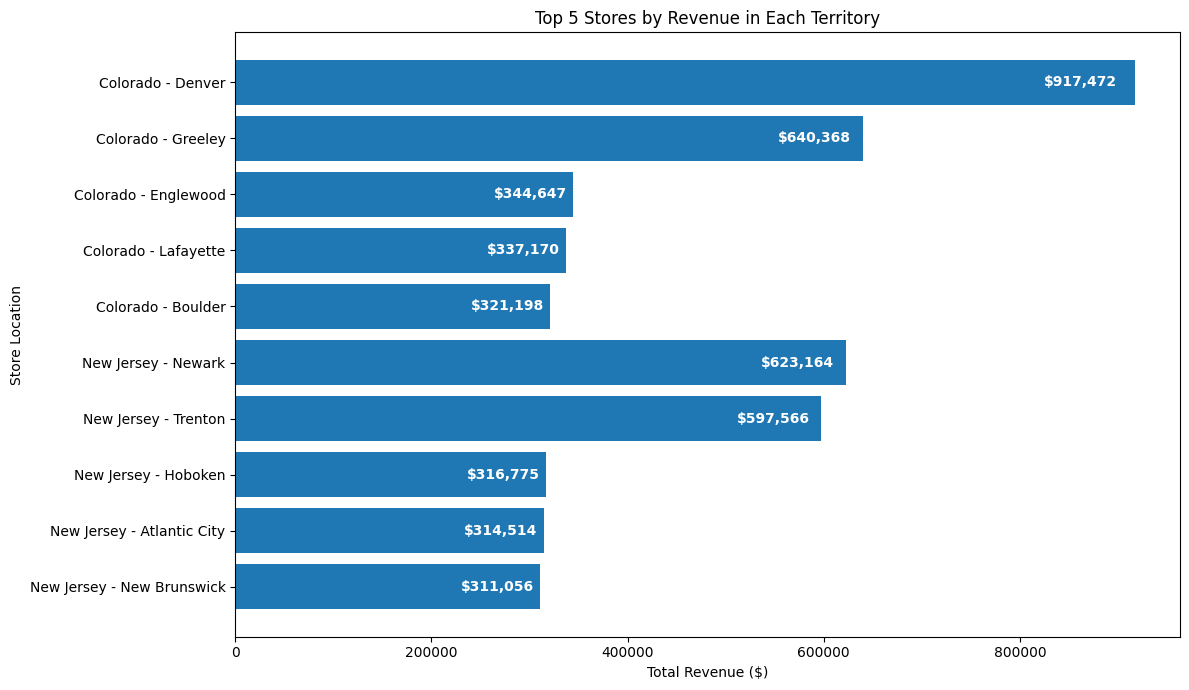

In [46]:
# Store performance ranking chart by territory
top_stores_by_territory = (
    store_ranking
    .groupby('State')
    .head(5)
)

top_stores_by_territory['Store Label'] = (
    top_stores_by_territory['State']
    + ' - '
    + top_stores_by_territory['Store Location']
)

plt.figure(figsize=(12, 7))

bars = plt.barh(
    top_stores_by_territory['Store Label'],
    top_stores_by_territory['Sale Amount']
)

plt.gca().invert_yaxis()

# Adding amount labels inside the bars
for bar in bars:
    width = bar.get_width()

    plt.text(
        width * 0.98,  # moves text slightly inside
        bar.get_y() + bar.get_height() / 2,
        f'${width:,.0f}',
        va='center',
        ha='right',
        color='white',
        fontweight='bold'
    )

plt.title('Top 5 Stores by Revenue in Each Territory')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Store Location')

plt.tight_layout()
plt.show()

Store performance varied by territory. Denver was the top location, generating approximately **$917K** in total revenue. In Colorado, Denver and Greeley outperformed other stores, while Newark and Trenton led in New Jersey.

These results indicate that top-performing stores likely benefit from strong customer demand or effective local marketing. Lower-performing locations may improve by adopting strategies used by the leading stores.